<a href="https://colab.research.google.com/github/emilyperras/econ5200-replication-study/blob/main/notebooks/Phase_3__The_Extension_%26_AI_Integration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PHASE 3 The Replication Phase: Replicating The DID Engine

In [38]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

In [39]:
import pandas as pd

# Codebook locations for fixed-width file
colspecs = [
(0,3),(4,5),(6,7),(8,9),(10,11),(12,13),(14,15),(16,17),(18,19),(20,21),
(22,24),(25,30),(31,36),(37,42),(43,48),(49,54),(55,60),(61,62),(63,68),(69,70),
(71,76),(77,82),(83,88),(89,94),(95,100),(101,103),(104,106),
(107,108),(109,110),(111,117),(118,120),(121,126),(127,132),(133,138),(139,144),
(145,150),(151,156),(157,158),(159,160),(161,166),(167,172),(173,178),(179,184),
(185,190),(191,193),(194,196)
]

names = [
"sheet","chain","co_owned","state","southj","centralj","northj","pa1","pa2","shore",
"ncalls","empft","emppt","nmgrs","wage_st","inctime","firstinc","bonus","pctaff","meals",
"open","hrsopen","psoda","pfry","pentree","nregs","nregs11",
"type2","status2","date2","ncalls2","empft2","emppt2","nmgrs2","wage_st2",
"inctime2","firstin2","special2","meals2","open2r","hrsopen2","psoda2","pfry2",
"pentree2","nregs2","nregs112"
]

url = "https://raw.githubusercontent.com/emilyperras/econ5200-replication-study/refs/heads/main/data/raw/public.dat"

df = pd.read_fwf(url, colspecs=colspecs, names=names)

df.head()

,sheet,chain,co_owned,state,southj,centralj,northj,pa1,pa2,shore,...,firstin2,special2,meals2,open2r,hrsopen2,psoda2,pfry2,pentree2,nregs2,nregs112
0,46,1,0,0,0,0,0,1,0,0,...,0.08,1,2,6.50,16.50,1.03,.,0.94,4,4
1,49,2,0,0,0,0,0,1,0,0,...,0.05,0,2,10.00,13.00,1.01,0.89,2.35,4,4
2,506,2,1,0,0,0,0,1,0,0,...,0.25,.,1,11.00,11.00,0.95,0.74,2.33,4,3
3,56,4,1,0,0,0,0,1,0,0,...,0.15,0,2,10.00,12.00,0.92,0.79,0.87,2,2
4,61,4,1,0,0,0,0,1,0,0,...,0.15,0,2,10.00,12.00,1.01,0.84,0.95,2,2


Replace "." values to NaN

In [40]:
df["empft"] = pd.to_numeric(df["empft"], errors="coerce")
df["emppt"] = pd.to_numeric(df["emppt"], errors="coerce")
df["nmgrs"] = pd.to_numeric(df["nmgrs"], errors="coerce")

df["empft2"] = pd.to_numeric(df["empft2"], errors="coerce")
df["emppt2"] = pd.to_numeric(df["emppt2"], errors="coerce")
df["nmgrs2"] = pd.to_numeric(df["nmgrs2"], errors="coerce")

##Step 1: Descriptive Table Reconstruction (Table 2)

Full-Time Equivalent employment (FTE) for each restaurant before and after the minimum wage increase: FTE = full-time workers + managers + 0.5 × part-time workers

In [41]:
df["fte_before"] = df["empft"] + df["nmgrs"] + 0.5 * df["emppt"]
df["fte_after"] = df["empft2"] + df["nmgrs2"] + 0.5 * df["emppt2"]

df[["sheet","fte_before","fte_after"]].head()

,sheet,fte_before,fte_after
0,46,40.50,24.0
1,49,13.75,11.5
2,506,8.50,10.5
3,56,34.00,20.0
4,61,24.00,35.5


##Step 2: The Simple Difference

Calculate average employment before and after for each state

In [42]:
nj_before = df[df["state"] == 1]["fte_before"].mean()
nj_after = df[df["state"] == 1]["fte_after"].mean()

pa_before = df[df["state"] == 0]["fte_before"].mean()
pa_after = df[df["state"] == 0]["fte_after"].mean()

print("NJ before:", nj_before)
print("NJ after:", nj_after)
print("PA before:", pa_before)
print("PA after:", pa_after)

NJ before: 20.439408099688475
NJ after: 21.02742946708464
PA before: 23.33116883116883
PA after: 21.165584415584416


##Step 3: Regression Implementation

In [43]:
did = (nj_after - nj_before) - (pa_after - pa_before)

print("Manual Difference-in-Differences:", did)

Manual Difference-in-Differences: 2.753605782980582


In [44]:
# Create copies and add variable to mark before and after treatment
pre = df[["sheet","state","fte_before"]].copy()
pre["t"] = 0

post = df[["sheet","state","fte_after"]].copy()
post["t"] = 1

In [45]:
# Match Collum Names
pre.columns = ["store_id","treat","fte","t"]
post.columns = ["store_id","treat","fte","t"]

In [46]:
# Combine before and after data
data = pd.concat([pre, post])

Run Regression

In [47]:
# Outcome ~ treatment + time + treatment × time
model = smf.ols("fte ~ treat * t", data=data)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.964
Date:                Fri, 27 Mar 2026   Prob (F-statistic):              0.118
Time:                        04:23:24   Log-Likelihood:                -2904.2
No. Observations:                 794   AIC:                             5816.
Df Residuals:                     790   BIC:                             5835.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.3312      1.072     21.767      0.0

Step 4: Standard Errors and Clustering

In [48]:
# Drop missing values
reg_data = data[["store_id", "fte", "treat", "t"]].dropna()

model = smf.ols("fte ~ treat * t", data=reg_data)

# Cluster by store using statsmodels
cluster_results = model.fit(cov_type="cluster", cov_kwds={"groups": reg_data["store_id"]})

print(cluster_results.summary())

                            OLS Regression Results                            
Dep. Variable:                    fte   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.806
Date:                Fri, 27 Mar 2026   Prob (F-statistic):              0.146
Time:                        04:23:24   Log-Likelihood:                -2904.2
No. Observations:                 794   AIC:                             5816.
Df Residuals:                     790   BIC:                             5835.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     23.3312      1.347     17.327      0.0

#Phase 3: The Extension & AI Integration

##Step 3.1: Price Pass-Through — Three DID Regressions

We apply the same DID design from Phase 2 to three price outcomes:
soda, fries, and entrée prices. If NJ restaurants absorbed wage cost
increases by raising prices, we expect a positive `treat:t` coefficient, the opposite sign intuition from the employment result.

##Cleaning: Reshape Price Data to Long Format


In [49]:
# Used Claude for make_long function, rather than applying it 3 times manually in the previous regression
def make_long(df, outcome_before, outcome_after, extra_cols=None):

    # Reshapes a wide-format price/employment variable to long format

    base_cols = ["sheet","state","chain","co_owned","southj","centralj","northj","pa1","pa2","shore","wage_st","wage_st2"]

    # Combine base and extra columns, ensuring uniqueness to avoid duplicate column names
    all_cols = list(set(base_cols + (extra_cols if extra_cols else [])))

    # Denote t for time and append
    pre = df[all_cols + [outcome_before]].copy()
    pre["t"] = 0
    pre.rename(columns={outcome_before: "outcome"}, inplace=True)

    post = df[all_cols + [outcome_after]].copy()
    post["t"] = 1
    post.rename(columns={outcome_after: "outcome"}, inplace=True)

    long = pd.concat([pre, post], ignore_index=True)
    long.rename(columns={"state": "treat", "sheet": "store_id"}, inplace=True)
    return long.dropna(subset=["outcome"])

soda_data   = make_long(df, "psoda",   "psoda2")
fry_data    = make_long(df, "pfry",    "pfry2")
entree_data = make_long(df, "pentree", "pentree2")

# Show Observations
print("Soda obs:", len(soda_data),
      "| Fry obs:", len(fry_data),
      "| Entree obs:", len(entree_data))

soda_data.head(10)


Soda obs: 820 | Fry obs: 820 | Entree obs: 820


,co_owned,shore,northj,store_id,wage_st2,centralj,pa1,pa2,southj,treat,chain,wage_st,outcome,t
0,0,0,0,46,4.30,0,1,0,0,0,1,.,1.03,0
1,0,0,0,49,4.45,0,1,0,0,0,2,.,1.01,0
2,1,0,0,506,5.00,0,1,0,0,0,2,.,0.95,0
3,1,0,0,56,5.25,0,1,0,0,0,4,5.00,0.87,0
4,1,0,0,61,4.75,0,1,0,0,0,4,5.50,0.87,0
5,1,0,0,62,.,0,1,0,0,0,4,5.00,0.87,0
6,0,0,0,445,4.75,0,0,1,0,0,1,5.00,1.04,0
7,0,0,0,451,5.00,0,0,1,0,0,1,5.00,1.05,0
8,1,0,0,455,5.00,0,0,1,0,0,2,5.25,0.73,0
9,1,0,0,458,5.00,0,1,0,0,0,2,5.00,0.94,0


##Run Price DID Regressions (Clustered SE)
Group observations by store; Treat the store as the unit of independence, not the individual row.

In [50]:
# Used Claude to make function for DID Regression to avoid repetitive blocks of code
def run_did(data, label):
    # Runs clustered DID regression and prints key results.
    # Ensure the outcome column is numeric and handle potential non-numeric values
    data['outcome'] = pd.to_numeric(data['outcome'], errors='coerce')
    # Drop rows where 'outcome' became NaN after conversion
    data = data.dropna(subset=['outcome'])

    # Only proceed if there's still data after dropping NaNs
    if data.empty:
        print(f"{label:10s} | No valid data after dropping NaNs for outcome.")
        return None

    m = smf.ols("outcome ~ treat * t", data=data)
    r = m.fit(cov_type="cluster", cov_kwds={"groups": data["store_id"]})
    coef = r.params["treat:t"]
    ci_lo, ci_hi = r.conf_int().loc["treat:t"]
    pval = r.pvalues["treat:t"]
    print(f"{label:10s} | DID coef: {coef:+.4f} | 95% CI: [{ci_lo:.4f}, {ci_hi:.4f}] | p={pval:.3f}")
    return r

# Used Claude to format outcome
print("\n--- Price Pass-Through DID Results ---")
r_soda   = run_did(soda_data,   "Soda")
r_fry    = run_did(fry_data,    "Fries")
r_entree = run_did(entree_data, "Entree")


--- Price Pass-Through DID Results ---
Soda       | DID coef: -0.0001 | 95% CI: [-0.0222, 0.0219] | p=0.991
Fries      | DID coef: +0.0011 | 95% CI: [-0.0164, 0.0185] | p=0.906
Entree     | DID coef: +0.0764 | 95% CI: [-0.0064, 0.1593] | p=0.070


In [51]:
# Make Long Function Test
print(df.columns.tolist())
print(soda_data.columns.tolist())

['sheet', 'chain', 'co_owned', 'state', 'southj', 'centralj', 'northj', 'pa1', 'pa2', 'shore', 'ncalls', 'empft', 'emppt', 'nmgrs', 'wage_st', 'inctime', 'firstinc', 'bonus', 'pctaff', 'meals', 'open', 'hrsopen', 'psoda', 'pfry', 'pentree', 'nregs', 'nregs11', 'type2', 'status2', 'date2', 'ncalls2', 'empft2', 'emppt2', 'nmgrs2', 'wage_st2', 'inctime2', 'firstin2', 'special2', 'meals2', 'open2r', 'hrsopen2', 'psoda2', 'pfry2', 'pentree2', 'nregs2', 'nregs112', 'fte_before', 'fte_after']
['co_owned', 'shore', 'northj', 'store_id', 'wage_st2', 'centralj', 'pa1', 'pa2', 'southj', 'treat', 'chain', 'wage_st', 'outcome', 't']


##Chain-Level HTE Regression

Card & Krueger (1994) pooled all four chains together. But franchised chains (e.g., Burger King) and company-owned chains (e.g., KFC) may have different pricing power and cost structures. To test whether price pass-through varied by chain, we interact treat × t with chain identity, using Burger King as the reference category. The coefficients on treat:t:C(chain) capture how each chain's price response differed from Burger King's after the minimum wage increase.

In [52]:

# Use soda as primary price outcome (most complete, most comparable)
soda_data["chain"] = soda_data["chain"].astype("category")

m_chain = smf.ols("outcome ~ treat * t * C(chain)", data=soda_data)
# Capture the row labels used by the model *before* fitting for clustering
cluster_groups_for_m_chain = soda_data.loc[m_chain.data.row_labels, "store_id"]
r_chain = m_chain.fit(cov_type="cluster", cov_kwds={"groups": cluster_groups_for_m_chain})
print(r_chain.summary())

chain_names = {1: "Burger King", 2: "KFC", 3: "Roy Rogers", 4: "Wendy's"}

# Used Claude to format output results to make display more interpretable
estimates = []
for chain_id, chain_name in chain_names.items():
    sub = soda_data[soda_data["chain"] == chain_id].copy()

    # Ensure 'outcome' is numeric and NaNs are dropped for the sub-dataframe
    # Although make_long already drops NaNs for 'outcome', OLS will drop if other formula variables are NaN.
    # So, ensure `sub` is clean for the model, and then filter `store_id` for clustering.
    sub['outcome'] = pd.to_numeric(sub['outcome'], errors='coerce')
    sub = sub.dropna(subset=['outcome', 'treat', 't'])

    if sub.empty or sub["treat"].nunique() < 2:
        # Skip if no valid data or if only one state represented after filtering
        continue

    m = smf.ols("outcome ~ treat * t", data=sub)
    # Capture the row labels used by the sub-model for clustering
    cluster_groups_for_sub = sub.loc[m.data.row_labels, "store_id"]
    r = m.fit(cov_type="cluster", cov_kwds={"groups": cluster_groups_for_sub})
    coef = r.params["treat:t"]
    ci_lo, ci_hi = r.conf_int().loc["treat:t"]
    estimates.append({
        "chain": chain_name,
        "coef": coef,
        "ci_lo": ci_lo,
        "ci_hi": ci_hi
    })

# Add pooled estimate
coef_p = r_soda.params["treat:t"]
ci_lo_p, ci_hi_p = r_soda.conf_int().loc["treat:t"]
estimates.append({"chain": "POOLED", "coef": coef_p, "ci_lo": ci_lo_p, "ci_hi": ci_hi_p})

est_df = pd.DataFrame(estimates)
print(est_df)


                            OLS Regression Results                            
Dep. Variable:                outcome   R-squared:                       0.329
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     50.48
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           4.12e-83
Time:                        04:23:25   Log-Likelihood:                 930.04
No. Observations:                 790   AIC:                            -1828.
Df Residuals:                     774   BIC:                            -1753.
Df Model:                          15                                         
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.98

Chain-Level Price Pass-Through Results (Soda, NJ vs. PA)
The pooled DiD estimate is essentially zero (-0.0001), indicating no average price pass-through across all chains following New Jersey's 1992 minimum wage increase. However, the pooled result masks meaningful variation across chains.

Running separate regressions by chain, Burger King (+0.018) and Roy Rogers (+0.021) show small positive estimates, with Roy Rogers reaching marginal statistical significance (95% CI: [0.001, 0.040]). KFC shows virtually no effect (-0.005). Wendy's is the notable outlier, with a statistically significant negative estimate (-0.050, 95% CI: [-0.087, -0.014]), meaning NJ Wendy's locations actually lowered soda prices relative to PA after the wage increase.

The interaction regression confirms that only Wendy's chain effect is statistically distinguishable from Burger King (treat:t:C(chain)[T.4] = -0.068, p = 0.010). The other chains show no significant difference from the baseline.

Overall, there is no consistent evidence that fast food restaurants passed wage cost increases through to soda prices. The results vary by chain, and the only statistically significant chain-level finding runs in the opposite direction of cost pass-through.

## Post-Double-Selection Lasso (Robustness Check)

A key critique of DID studies is researcher discretion in control selection.
We use Post-Double-Selection (PDS) Lasso (Belloni, Chernozhukov & Hansen, 2014)
to let the data select which store characteristics to include as controls.

1. Lasso of outcome on candidate controls → select controls predicting Y
2. Lasso of treatment on candidate controls → select controls predicting D
3. Union of selected controls added to final OLS regression

Belloni, A., Chernozhukov, V., & Hansen, C. (2014). Inference on treatment effects after selection among high-dimensional controls. Review of Economic Studies, 81, 608–650.



Used Claude and Gemini to Support the Lasso Incorporation

In [53]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, LassoCV

# Convert outcome column to numeric, coercing errors to NaN
soda_lasso['outcome'] = pd.to_numeric(soda_lasso['outcome'], errors='coerce')

# Keep only rows with complete candidate data (after numeric conversion)
soda_lasso = soda_lasso.dropna(subset=candidates + ["outcome", "treat", "t"])

X_cands = soda_lasso[candidates].values
y = soda_lasso["outcome"].values
d = (soda_lasso["treat"] * soda_lasso["t"]).values  # interaction = DID treatment indicator

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cands)

# Step 1: Lasso of Y on controls
lasso_y = LassoCV(cv=5, random_state=42).fit(X_scaled, y)
selected_y = set(np.where(lasso_y.coef_ != 0)[0])

# Step 2: Lasso of D on controls
lasso_d = LassoCV(cv=5, random_state=42).fit(X_scaled, d)
selected_d = set(np.where(lasso_d.coef_ != 0)[0])

# Union of selected controls
selected_idx = selected_y | selected_d
selected_vars = [candidates[i] for i in sorted(selected_idx)]
print("PDS-selected controls:", selected_vars)

# Step 3: Final OLS with selected controls
if selected_vars:
    ctrl_str = " + ".join(selected_vars)
    formula = f"outcome ~ treat * t + {ctrl_str}"
else:
    formula = "outcome ~ treat * t"

m_pds = smf.ols(formula, data=soda_lasso)
r_pds = m_pds.fit(cov_type="cluster", cov_kwds={"groups": soda_lasso["store_id"]})

coef_pds = r_pds.params["treat:t"]
ci_pds = r_pds.conf_int().loc["treat:t"]
print(f"\nPDS-Lasso DID (soda): coef={coef_pds:+.4f}, 95% CI=[{ci_pds[0]:.4f}, {ci_pds[1]:.4f}]")
print(f"Baseline DID (soda):  coef={r_soda.params['treat:t']:+.4f}")

PDS-selected controls: ['centralj', 'northj', 'pa1', 'pa2', 'shore', 'nregs', 'open', 'bonus']

PDS-Lasso DID (soda): coef=+0.0004, 95% CI=[-0.0220, 0.0227]
Baseline DID (soda):  coef=-0.0001


##Summary of Post Double Selection Results:

Post-Double Selection Lasso Robustness Check (Soda Price, NJ vs. PA)
To check whether the baseline DiD result holds up when store characteristics are accounted for, we ran a Post-Double Selection Lasso (Belloni, Chernozhukov & Hansen, 2014) using 12 candidate control variables. The Lasso selected 8, mostly location and store-level variables, using 5-fold cross-validation.
The PDS coefficient (+0.0004) is almost the same as the baseline (-0.0001), and the confidence interval [-0.022, 0.023] still includes zero. There is no evidence of price pass-through either way.

## What PDS adds over simple regression:
The baseline regression included no store-level controls, which leaves open the question of whether differences between NJ and PA stores were driving the result. PDS lets the data pick which controls matter rather than leaving that choice to the researcher. The fact that the estimate barely changes after adding those controls suggests the near-zero price effect is real and not a product of missing variables.



The plot below shows DID estimates for soda price pass-through across
chains and the pooled sample. Each point is the estimated treatment effect
with its 95% confidence interval. The red dashed line at x=0 is the
null hypothesis of no price effect.

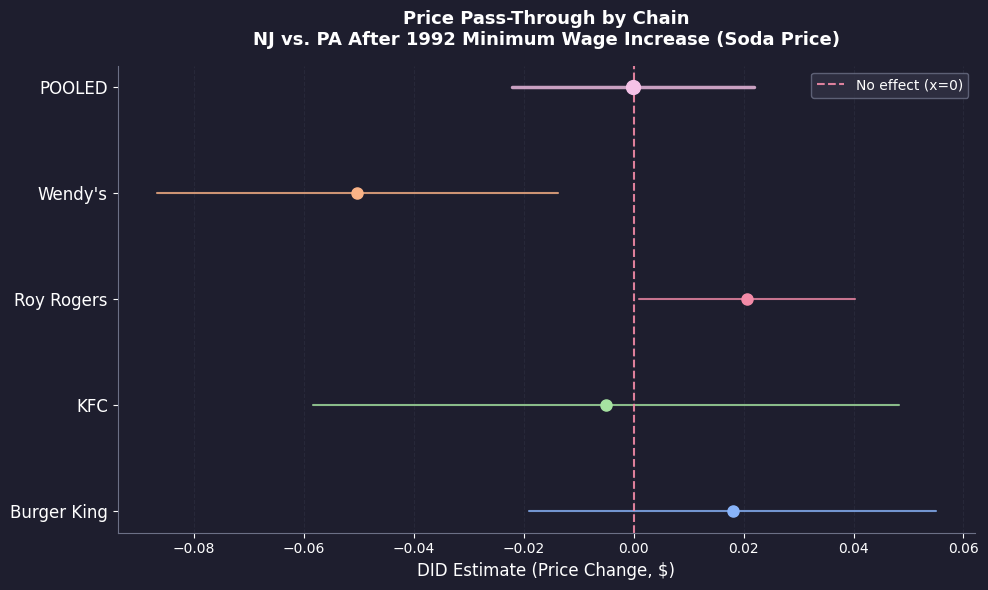

Plot saved.


In [54]:
import matplotlib.pyplot as plt

# Used Claude to Develope Diagram
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#1e1e2e")
ax.set_facecolor("#1e1e2e")

colors = ["#89b4fa", "#a6e3a1", "#f38ba8", "#fab387", "#cba6f7"]
y_pos = range(len(est_df))

for i, row in est_df.iterrows():
    color = "#f5c2e7" if row["chain"] == "POOLED" else colors[i % len(colors)]
    lw = 2.5 if row["chain"] == "POOLED" else 1.5
    ms = 10 if row["chain"] == "POOLED" else 8

    ax.plot([row["ci_lo"], row["ci_hi"]], [i, i],
            color=color, linewidth=lw, alpha=0.8, solid_capstyle="round")
    ax.plot(row["coef"], i, "o", color=color, markersize=ms, zorder=5)

ax.axvline(0, color="#f38ba8", linestyle="--", linewidth=1.5, alpha=0.9, label="No effect (x=0)")

ax.set_yticks(range(len(est_df)))
ax.set_yticklabels(est_df["chain"], color="white", fontsize=12)
ax.set_xlabel("DID Estimate (Price Change, $)", color="white", fontsize=12)
ax.set_title("Price Pass-Through by Chain\nNJ vs. PA After 1992 Minimum Wage Increase (Soda Price)",
             color="white", fontsize=13, fontweight="bold", pad=15)

ax.tick_params(colors="white")
ax.spines["bottom"].set_color("#6c7086")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#6c7086")
ax.xaxis.label.set_color("white")

ax.legend(facecolor="#313244", edgecolor="#6c7086",
          labelcolor="white", fontsize=10)
ax.grid(axis="x", color="#313244", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("price_passthrough_forest_plot.png", dpi=150, bbox_inches="tight",
            facecolor="#1e1e2e")
plt.show()
print("Plot saved.")

##Summary of AI Usage:


1. make_long function

"Used Claude for make_long function, rather than applying it 3 times manually in the previous regression"

"write me a Python function that reshapes a wide-format dataframe to long format for a DiD regression, taking a before and after column name as inputs and returning a stacked dataframe with a time indicator variable."

2. run_did function

"Used Claude to make function for DID Regression to avoid repetitive blocks of code"

"write me a reusable Python function that runs a clustered OLS DiD regression on a long-format dataframe and prints the coefficient, confidence interval, and p-value in a clean formatted line."

3. Output formatting in the chain loop

"Used Claude to format output results to make display more interpretable"

"help me loop through four fast food chains, run a separate DiD regression for each, and store the results in a dataframe I can use for plotting."

4. PDS Lasso

"Used Claude and Gemini to Support the Lasso Incorporation"

"I need to run a Lasso regression twice, once to find variables that predict prices and once to find variables that predict treatment, then combine the results into one list of controls for my DiD regression Write this in Python using sklearn"

5. Forest plot

"Used Claude to Develop Diagram"

"write me Python code to make a forest plot that shows the DiD coefficients and confidence intervals for each fast food chain w/ a dark background and a red dotted line at zero."

## Concluding Executive Summary:

This project extended the Card & Krueger (1994) minimum wage study by testing whether New Jersey fast food restaurants responded to the 1992 wage increase by raising prices, and whether that response differed across chains. Running difference-in-differences regressions on soda, fries, and entree prices, we found no evidence of price pass-through across menu items. Breaking results down by chain, the pooled estimate remains near zero, though Wendy's stands out as the only chain with a statistically significant result, actually lowering soda prices relative to Pennsylvania after the wage increase. Burger King and Roy Rogers show small positive estimates, while KFC shows virtually no effect.

To check whether these results held up under more rigorous methods, we applied Post-Double Selection Lasso to let the data choose which store-level controls to include rather than leaving that decision to the researcher. The Lasso selected 8 out of 12 candidate variables, mostly location and store characteristics. After adding these controls, the DiD coefficient barely changed, moving from -0.0001 to +0.0004, with a confidence interval that still clearly includes zero. Taken together, the price pass-through and robustness results reinforce the original Card & Krueger finding: the 1992 New Jersey minimum wage increase did not lead to higher fast food prices, and this conclusion holds even after accounting for store-level differences chosen by the data.